# 🏁 F1 Strategy Predictor
## Analisi Dati e Feature Engineering per Predizione Strategia

---

# 1. Setup e Import Dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os, sys
import json

# ML tools
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Uso della libreria Open FastF1
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

df_f1 = pd.read_pickle('f1_dataset_combined.pkl')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 2.14.0 requires websocket-client>=1.7, but you have websocket-client 1.0.0 which is incompatible.


In [3]:
def save_plot(fig, subfolder_name, filename):

    main_directory = 'Analysis'
    directory = os.path.join(main_directory, subfolder_name)

    if not os.path.exists(directory):
        os.makedirs(directory)

    file_path = os.path.join(directory, filename)
    fig.savefig(file_path, bbox_inches='tight')

    print(f"Grafico salvato in: {file_path}")

## Modifiche e Conversioni

In [4]:
# CONVERSIONE TIMEDELTA in secondi
temporal_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'PitOutTime', 'PitInTime']

for col in temporal_cols:
    if col in df_f1.columns:
        new_col = f'{col}Sec'
        df_f1[new_col] = df_f1[col].dt.total_seconds()

In [5]:
# UNIFICAZIONE NOMI TEAM (storico)
print(f"\nTeam: {df_f1['Team'].unique()}")

team_mapping = {
    # RB / Racing Bulls / AlphaTauri → Racing Bulls
    'RB': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',

    # Kick Sauber / Alfa Romeo → Kick Sauber
    'Alfa Romeo': 'Kick Sauber'
}

df_f1['Team'] = df_f1['Team'].replace(team_mapping)

print("\nTeam unificati:")
print(f"   AlphaTauri + RB → Racing Bulls")
print(f"   Alfa Romeo → Kick Sauber")
print(f"\nTeam: {df_f1['Team'].unique()}")


Team: ['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'AlphaTauri'
 'Alpine' 'Williams' 'Alfa Romeo' 'Aston Martin' 'McLaren' 'RB'
 'Kick Sauber' 'Racing Bulls']

Team unificati:
   AlphaTauri + RB → Racing Bulls
   Alfa Romeo → Kick Sauber

Team: ['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'Racing Bulls'
 'Alpine' 'Williams' 'Kick Sauber' 'Aston Martin' 'McLaren']


# 2. Analisi dei Dati

## Metriche base

In [6]:
# Overview
print(f"📦 Dimensioni Dataset:")
print(f"   Righe (giri):        {len(df_f1):,}")
print(f"   Colonne (features):  {len(df_f1.columns)}")

print(f"\n📅 Copertura Temporale:")
years = sorted(df_f1['Year'].unique())
print(f"   Anni:                {years}")
for year in years:
    n_races = df_f1[df_f1['Year'] == year]['Round'].nunique()
    n_laps = len(df_f1[df_f1['Year'] == year])
    print(f"   {year}: {n_races:2d} gare, {n_laps:,} giri")

print(f"\n🏁 Entità:")
print(f"   Gare totali:         {len(df_f1.groupby(['Year', 'Round']))}")
print(f"   Piloti unici:        {df_f1['Driver'].nunique()}")
print(f"   Team unici:          {df_f1['Team'].nunique()}")
print(f"   Circuiti unici:      {df_f1['Circuit'].nunique()}")

📦 Dimensioni Dataset:
   Righe (giri):        87,522
   Colonne (features):  52

📅 Copertura Temporale:
   Anni:                [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
   2022: 22 gare, 19,639 giri
   2023: 22 gare, 21,283 giri
   2024: 24 gare, 23,557 giri
   2025: 24 gare, 23,043 giri

🏁 Entità:
   Gare totali:         92
   Piloti unici:        31
   Team unici:          10
   Circuiti unici:      26


In [7]:
# Tipi di Dati (colonne presenti)
print(f"🔍 Tipi di Dati:\n")
for col in df_f1.columns:
    print(f"{col:30s}: {df_f1[col].dtype}")

🔍 Tipi di Dati:

Time                          : timedelta64[ns]
Driver                        : object
DriverNumber                  : object
LapTime                       : timedelta64[ns]
LapNumber                     : float64
Stint                         : float64
PitOutTime                    : timedelta64[ns]
PitInTime                     : timedelta64[ns]
Sector1Time                   : timedelta64[ns]
Sector2Time                   : timedelta64[ns]
Sector3Time                   : timedelta64[ns]
Sector1SessionTime            : timedelta64[ns]
Sector2SessionTime            : timedelta64[ns]
Sector3SessionTime            : timedelta64[ns]
SpeedI1                       : float64
SpeedI2                       : float64
SpeedFL                       : float64
SpeedST                       : float64
IsPersonalBest                : object
Compound                      : object
TyreLife                      : float64
FreshTyre                     : bool
Team                          

In [8]:
# Conteggio valori mancanti
print("❓ Valori Mancanti:")

missing = df_f1.isnull().sum()
missing_pct = (missing / len(df_f1) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentuale': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print(f"\nColonne con valori mancanti: {len(missing_df)}/{len(df_f1.columns)}\n")
print(missing_df.head(20))

❓ Valori Mancanti:

Colonne con valori mancanti: 15/52

                    Missing  Percentuale
PitOutTime            87522       100.00
PitInTime             87522       100.00
Deleted               87522       100.00
PitInTimeSec          87522       100.00
PitOutTimeSec         87522       100.00
LapStartDate          87522       100.00
SpeedI1               14909        17.03
SpeedST                7075         8.08
TyreLife                887         1.01
SpeedI2                 782         0.89
Stint                   382         0.44
StintLength             382         0.44
StintProgress           382         0.44
Sector1SessionTime      214         0.24
SpeedFL                   4         0.00


In [9]:
# Distribuzione dei Piloti
print(df_f1["Driver"].unique())

['LEC' 'VER' 'SAI' 'HAM' 'MAG' 'PER' 'RUS' 'GAS' 'ALO' 'OCO' 'ALB' 'TSU'
 'MSC' 'BOT' 'HUL' 'STR' 'NOR' 'ZHO' 'LAT' 'RIC' 'VET' 'DEV' 'SAR' 'PIA'
 'LAW' 'BEA' 'COL' 'DOO' 'ANT' 'BOR' 'HAD']


In [10]:
# Distribuzione dei Team
print(df_f1["Team"].unique())

['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'Racing Bulls'
 'Alpine' 'Williams' 'Kick Sauber' 'Aston Martin' 'McLaren']


In [11]:
# Distribuzione dei Circuiti
print(df_f1["Circuit"].unique())

['Sakhir' 'Jeddah' 'Melbourne' 'Imola' 'Miami' 'Barcelona' 'Monaco' 'Baku'
 'Montréal' 'Silverstone' 'Spielberg' 'Le Castellet' 'Budapest'
 'Spa-Francorchamps' 'Zandvoort' 'Monza' 'Marina Bay' 'Suzuka' 'Austin'
 'Mexico City' 'São Paulo' 'Yas Island' 'Lusail' 'Las Vegas' 'Shanghai'
 'Miami Gardens']


In [12]:
# Distribuzione delle Gomme Pirelli
print(df_f1["Compound"].unique())

['SOFT' 'MEDIUM' 'HARD' 'INTERMEDIATE' 'WET' 'None' 'nan']


In [13]:
# Statistiche LapTime
print(f"Statistiche Lap Time:\n")
if 'LapTimeSec' in df_f1.columns:
    # Filtra outlier (< 60s o > 200s sono pit lane / safety car)
    valid_laps = df_f1[(df_f1['LapTimeSec'] > 60) & (df_f1['LapTimeSec'] < 200)]

    print(f"   Giri totali:         {len(df_f1):,}")
    print(f"   Giri validi:         {len(valid_laps):,} ({len(valid_laps)/len(df_f1)*100:.1f}%)")
    print(f"   Min:                 {valid_laps['LapTimeSec'].min():.2f}s")
    print(f"   Max:                 {valid_laps['LapTimeSec'].max():.2f}s")
    print(f"   Media:               {valid_laps['LapTimeSec'].mean():.2f}s")
    print(f"   Mediana:             {valid_laps['LapTimeSec'].median():.2f}s")
    print(f"   Std Dev:             {valid_laps['LapTimeSec'].std():.2f}s")

Statistiche Lap Time:

   Giri totali:         87,522
   Giri validi:         87,522 (100.0%)
   Min:                 67.01s
   Max:                 149.32s
   Media:               89.05s
   Mediana:             87.41s
   Std Dev:             10.94s


## Metriche Approfondite

### Analisi Piloti

Grafico salvato in: Analysis/DriverAnalysis/driver_rank_laps


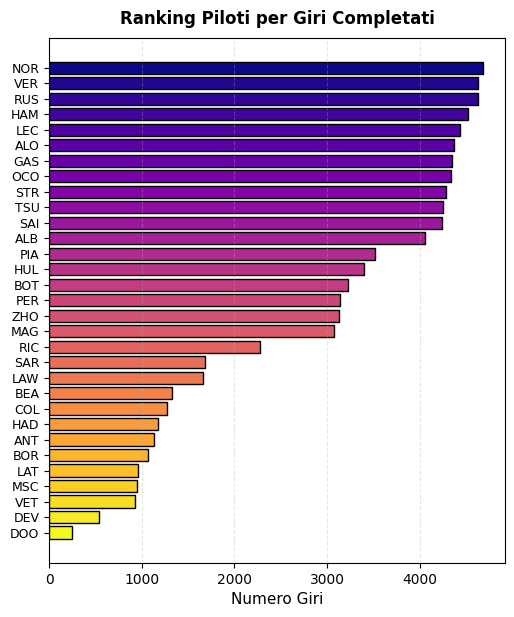

In [14]:
# Ranking Piloti per Giri Completati

fig = plt.figure(figsize=(20, 15))
ax = plt.subplot(2, 3, 1)
top_drivers = df_f1['Driver'].value_counts()
colors = plt.cm.plasma(np.linspace(0, 1, len(top_drivers)))
bars = ax.barh(range(len(top_drivers)), top_drivers.values, color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_drivers)))
ax.set_yticklabels(top_drivers.index, fontsize=9)
ax.set_xlabel('Numero Giri', fontsize=11)
ax.set_title('Ranking Piloti per Giri Completati', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_rank_laps")

Grafico salvato in: Analysis/DriverAnalysis/driver_position_distribution


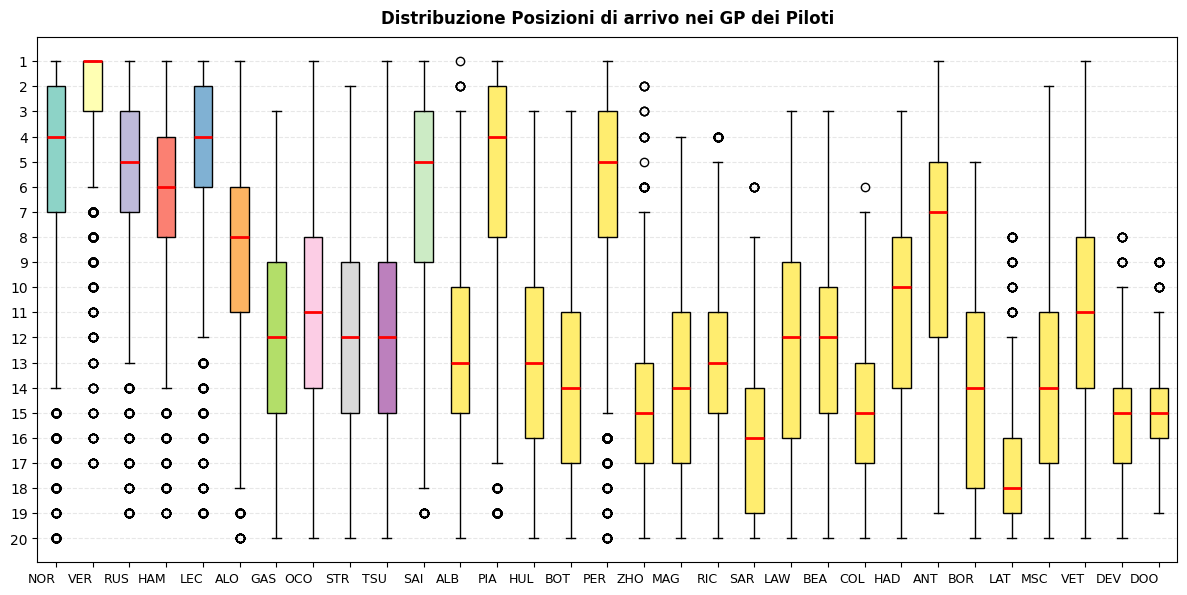

In [15]:
# Distribuzione delle Posizioni dei Piloti

fig = plt.figure(figsize=(50, 15))
ax = plt.subplot(2, 3, 3)
top_drivers = df_f1['Driver'].value_counts().index
data_to_plot = [df_f1[df_f1['Driver'] == driver]['Position'].dropna().values
                for driver in top_drivers]
bp = ax.boxplot(data_to_plot, labels=top_drivers, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(top_drivers)))):
    patch.set_facecolor(color)
ax.set_xticklabels(top_drivers, ha='right', fontsize=9)
ax.set_yticks(range(1, 21))
ax.set_title('Distribuzione Posizioni di arrivo nei GP dei Piloti', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_position_distribution")

Grafico salvato in: Analysis/DriverAnalysis/driver_avg_position


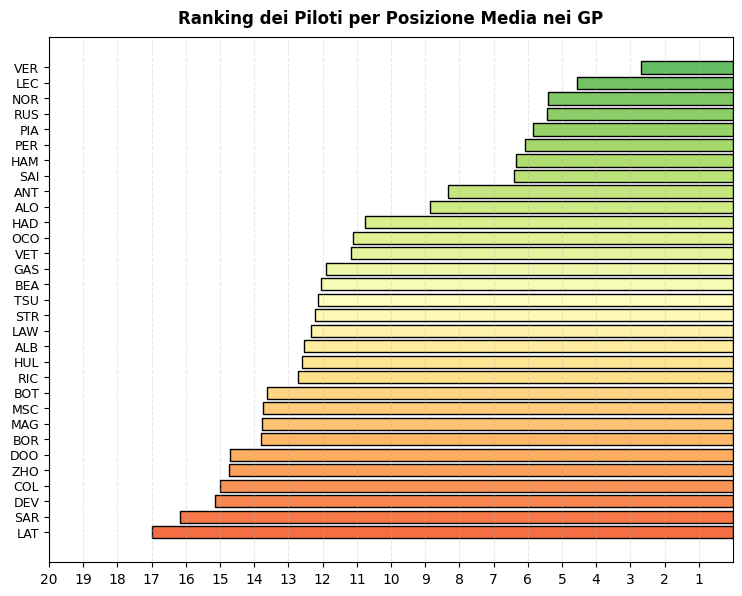

In [16]:
# Distribuzioni delle Medie Posizioni dei Piloti

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 5)
avg_position = df_f1.groupby('Driver')['Position'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(avg_position)))
bars = ax.barh(range(len(avg_position)), avg_position.values, color=colors,
                edgecolor='black', linewidth=1)
ax.set_yticks(range(len(avg_position)))
ax.set_yticklabels(avg_position.index, fontsize=9)
ax.set_xticks(range(1, 21))
ax.set_title('Ranking dei Piloti per Posizione Media nei GP', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.invert_xaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_avg_position")

Grafico salvato in: Analysis/DriverAnalysis/driver_participation_years


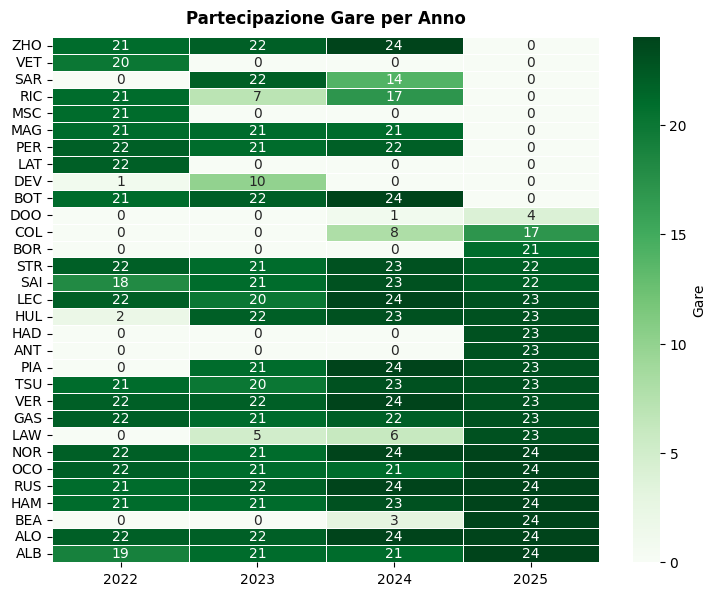

In [17]:
# Partecipazione dei Piloti alle Gare per ogni Anno

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 4)
ax.set_title('Partecipazione Gare per Anno', fontsize=12, fontweight='bold', pad=10)
participation = df_f1.groupby(['Year', 'Driver'])['Round'].nunique().reset_index()
participation_pivot = participation.pivot(index='Driver', columns='Year', values='Round').fillna(0)
participation_pivot = participation_pivot[participation_pivot.sum(axis=1) > 1].sort_values(
    by=participation_pivot.columns[-1], ascending=False)
sns.heatmap(participation_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax,
           linewidths=0.5, cbar_kws={'label': 'Gare'})
ax.set_xlabel('', fontsize=11, fontweight='bold')
ax.set_ylabel('', fontsize=11, fontweight='bold')
ax.invert_yaxis()

save_plot(fig, "DriverAnalysis", "driver_participation_years")

### Analisi Team

Grafico salvato in: Analysis/TeamAnalysis/team_rank_laps


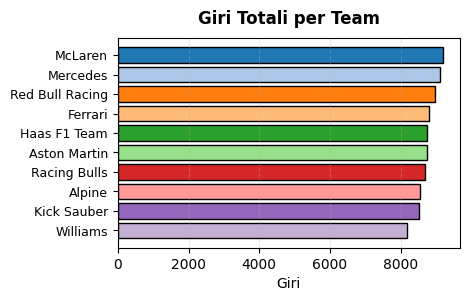

In [18]:
# Ranking Team per Giri Completati

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(2, 3, 3)
team_totals = df_f1['Team'].value_counts()
colors = plt.cm.tab20(range(len(team_totals)))
bars = ax.barh(range(len(team_totals)), team_totals.values, color=colors,
                edgecolor='black', linewidth=1)
ax.set_yticks(range(len(team_totals)))
ax.set_yticklabels(team_totals.index, fontsize=9)
ax.set_xlabel('Giri')
ax.set_title('Giri Totali per Team', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "TeamAnalysis", "team_rank_laps")

Grafico salvato in: Analysis/TeamAnalysis/team_participation_years


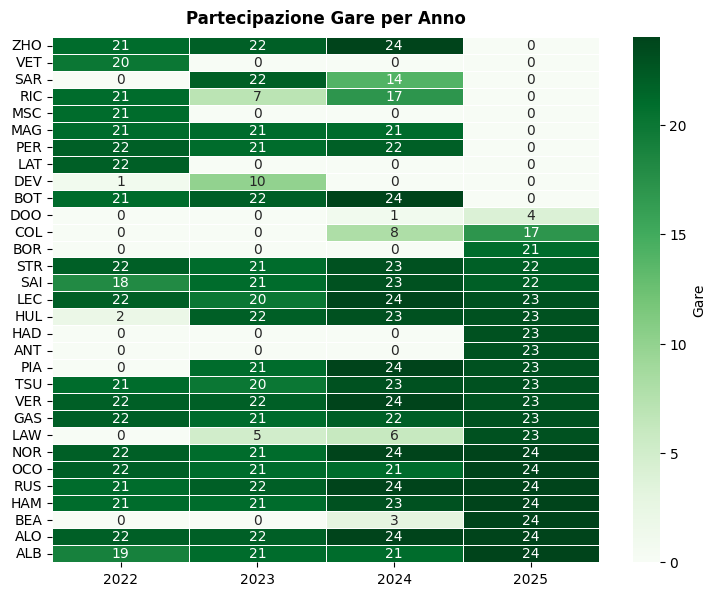

In [19]:
# Partecipazione dei Piloti alle Gare per ogni Anno

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 4)
ax.set_title('Partecipazione Gare per Anno', fontsize=12, fontweight='bold', pad=10)
participation = df_f1.groupby(['Year', 'Driver'])['Round'].nunique().reset_index()
participation_pivot = participation.pivot(index='Driver', columns='Year', values='Round').fillna(0)
participation_pivot = participation_pivot[participation_pivot.sum(axis=1) > 1].sort_values(
    by=participation_pivot.columns[-1], ascending=False)
sns.heatmap(participation_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax,
           linewidths=0.5, cbar_kws={'label': 'Gare'})
ax.set_xlabel('', fontsize=11, fontweight='bold')
ax.set_ylabel('', fontsize=11, fontweight='bold')
ax.invert_yaxis()

save_plot(fig, "TeamAnalysis", "team_participation_years")

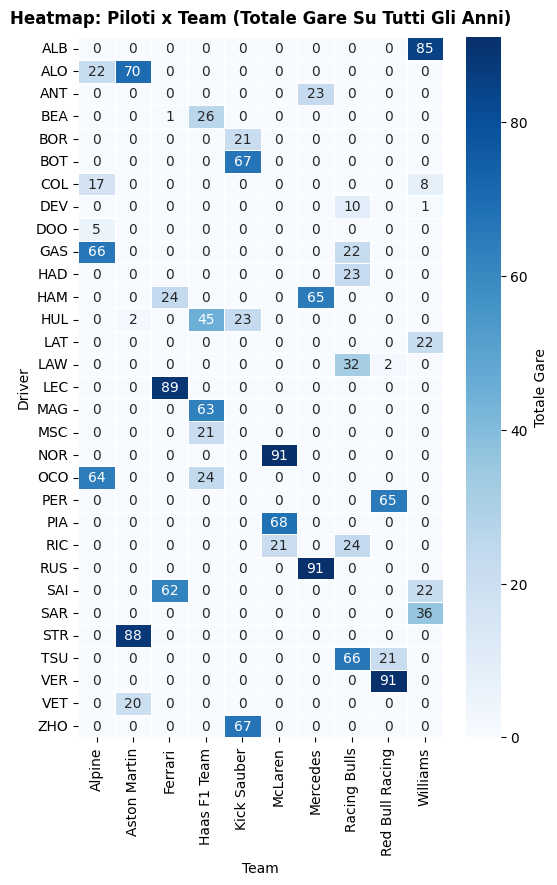

Grafico salvato in: Analysis/TeamAnalysis/team_participation_drivers


In [20]:
# Partecipazione dei Piloti alle Gare per ogni Team

fig = plt.figure(figsize=(20, 20))
ax = plt.subplot(2, 3, 4)
top_drivers = df_f1['Driver'].value_counts().index
pivot_driver_team = df_f1[df_f1['Driver'].isin(top_drivers)].pivot_table(
    values='Round',
    index=['Driver', 'Year'],
    columns='Team',
    aggfunc='nunique',
    fill_value=0
)
pivot_driver_team_total = pivot_driver_team.groupby(level='Driver').sum()
sns.heatmap(pivot_driver_team_total, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Totale Gare'})
ax.set_title('Heatmap: Piloti x Team (Totale Gare Su Tutti Gli Anni)', fontsize=12, fontweight='bold', pad=10)
plt.show()

save_plot(fig, "TeamAnalysis", "team_participation_drivers")

Grafico salvato in: Analysis/TeamAnalysis/team_position_distribution


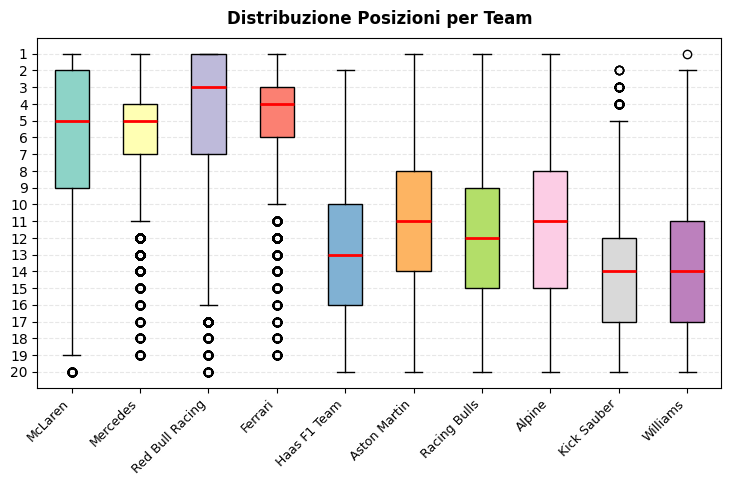

In [21]:
# Distribuzione delle Posizione nei GP per Team

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 5)
top_teams = df_f1['Team'].value_counts().index
data_to_plot = [df_f1[df_f1['Team'] == team]['Position'].dropna().values
                for team in top_teams]
bp = ax.boxplot(data_to_plot, labels=top_teams, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(top_teams)))):
    patch.set_facecolor(color)
ax.set_yticks(range(1, 21))
ax.set_xticklabels(top_teams, rotation=45, ha='right', fontsize=9)
ax.set_title('Distribuzione Posizioni per Team', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')

save_plot(fig, "TeamAnalysis", "team_position_distribution")

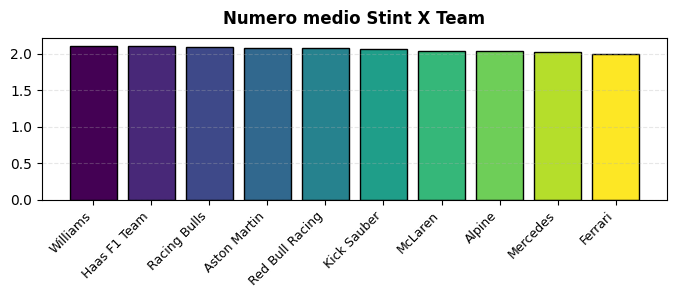

Grafico salvato in: Analysis/TeamAnalysis/team_stint_length


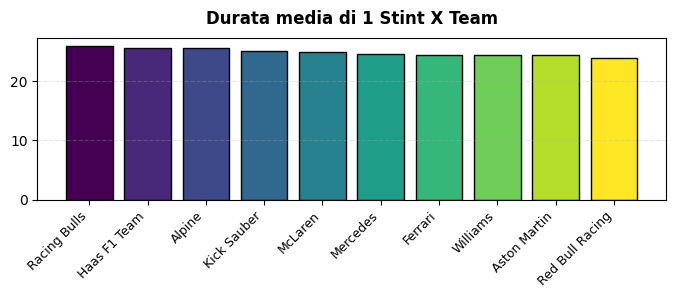

In [22]:
# Distribuzione dei Cambi Gomma medi per Team

fig = plt.figure(figsize=(20, 5))
ax = plt.subplot(2, 3, 6)
if 'Stint' in df_f1.columns:
    stint_by_team = df_f1[df_f1['Team'].isin(top_teams)].groupby('Team')['Stint'].mean().sort_values(ascending=False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(stint_by_team)))
    bars = ax.bar(range(len(stint_by_team)), stint_by_team.values, color=colors,
                   edgecolor='black', linewidth=1)
    ax.set_xticks(range(len(stint_by_team)))
    ax.set_xticklabels(stint_by_team.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('Numero medio Stint X Team', fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


fig = plt.figure(figsize=(20, 5))
ax = plt.subplot(2, 3, 6)
if 'Stint' in df_f1.columns:
    stint_by_team = df_f1[df_f1['Team'].isin(top_teams)].groupby('Team')['StintLength'].mean().sort_values(ascending=False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(stint_by_team)))
    bars = ax.bar(range(len(stint_by_team)), stint_by_team.values, color=colors,
                   edgecolor='black', linewidth=1)
    ax.set_xticks(range(len(stint_by_team)))
    ax.set_xticklabels(stint_by_team.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('Durata media di 1 Stint X Team', fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout(rect=[0, 0, 1, 0.97])

save_plot(fig, "TeamAnalysis", "team_stint_length")

### Analisi Gomme

Grafico salvato in: Analysis/CompoundAnalysis/compound_distribution


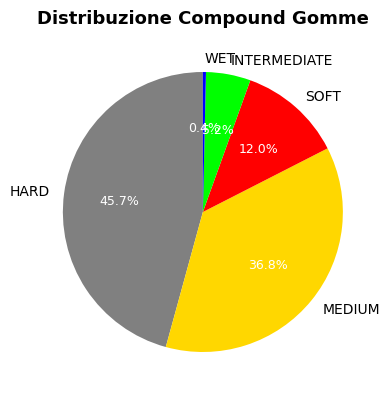

In [23]:
# Distribuzione Compound Utilizzati
fig = plt.figure(figsize=(30, 10))

ax = plt.subplot(2, 3, 4)
compound_colors = {
    'HARD': '#808080', 'WET': '#0000FF', 'MEDIUM': '#FFD700', 'SOFT': '#FF0000',
    'INTERMEDIATE': '#00FF00'}

compound_data = df_f1['Compound'].value_counts().dropna()
compound_data = compound_data[compound_data.index.isin(compound_colors.keys())]
colors = [compound_colors.get(c, '#CCCCCC') for c in compound_data.index]
wedges, texts, autotexts = ax.pie(compound_data.values, labels=compound_data.index,
                                    autopct='%1.1f%%', startangle=90, colors=colors,
                                    )
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
ax.set_title('Distribuzione Compound Gomme', fontsize=13, fontweight='bold', pad=10)

save_plot(fig, "CompoundAnalysis", "compound_distribution")

Grafico salvato in: Analysis/CompoundAnalysis/stint_length_distribution


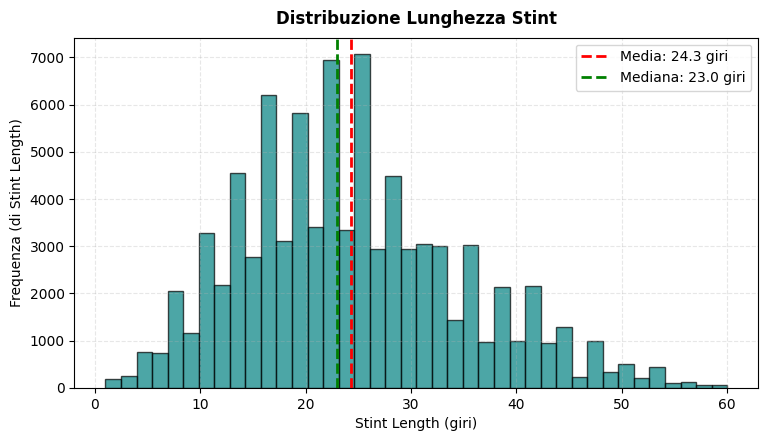

In [24]:
# Distribuzione Lunghezza Stint

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 2)
if 'StintLength' in df_f1.columns:
    stint_lengths = df_f1['StintLength'].dropna()
    stint_lengths = stint_lengths[(stint_lengths > 0) & (stint_lengths <= 60)]
    ax.hist(stint_lengths, bins=40, edgecolor='black', alpha=0.7, color='teal')
    mean_stint = stint_lengths.mean()
    median_stint = stint_lengths.median()
    ax.axvline(mean_stint, color='red', linestyle='--', linewidth=2,
               label=f'Media: {mean_stint:.1f} giri')
    ax.axvline(median_stint, color='green', linestyle='--', linewidth=2,
               label=f'Mediana: {median_stint:.1f} giri')
    ax.set_xlabel('Stint Length (giri)')
    ax.set_ylabel('Frequenza (di Stint Length)')
    ax.set_title('Distribuzione Lunghezza Stint', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "stint_length_distribution")

Grafico salvato in: Analysis/CompoundAnalysis/compound_degradation


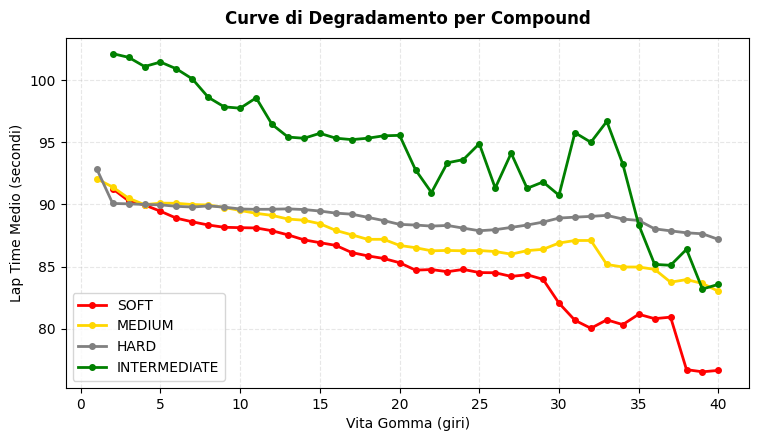

In [25]:
# Degradamento per Tipo di Gomma

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 1)
if 'LapTimeSec' in df_f1.columns and 'TyreLife' in df_f1.columns:
    for compound, color in [('SOFT', 'red'), ('MEDIUM', 'gold'), ('HARD', 'grey'), ('INTERMEDIATE', 'green')]:
        compound_data = df_f1[
            (df_f1['Compound'] == compound) &
            (df_f1['TyreLife'] <= 40)
        ]
        if len(compound_data) > 0:
            degradation = compound_data.groupby('TyreLife')['LapTimeSec'].mean()
            ax.plot(degradation.index, degradation.values,
                    marker='o', label=compound, color=color, linewidth=2, markersize=4)
    ax.set_xlabel('Vita Gomma (giri)')
    ax.set_ylabel('Lap Time Medio (secondi)')
    ax.set_title('Curve di Degradamento per Compound', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "compound_degradation")

Grafico salvato in: Analysis/CompoundAnalysis/compound_tyrelife_distribution


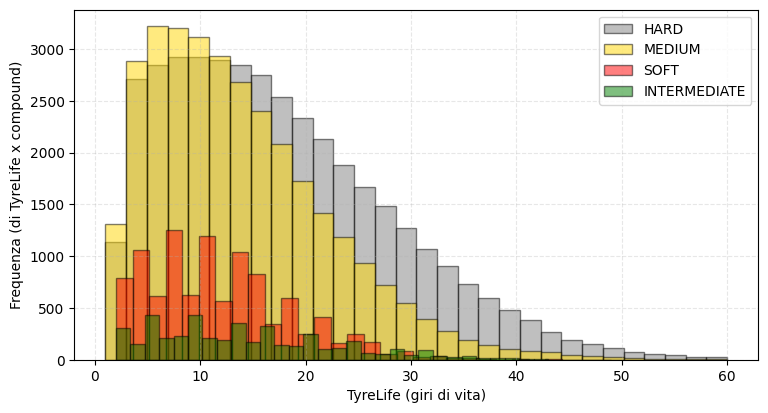

In [26]:
# Frequenza del Numero di Giri Compiuti per ogni Compound

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 4)
if 'TyreLife' in df_f1.columns:
    for compound, color in [ ('HARD', 'grey'), ('MEDIUM', 'gold'), ('SOFT', 'red'), ('INTERMEDIATE', 'green')]:
        compound_tyrelife = df_f1[df_f1['Compound'] == compound]['TyreLife'].dropna()
        compound_tyrelife = compound_tyrelife[compound_tyrelife <= 60]
        ax.hist(compound_tyrelife, bins=30, alpha=0.5, label=compound,
                color=color, edgecolor='black')
    ax.set_xlabel('TyreLife (giri di vita)')
    ax.set_ylabel('Frequenza (di TyreLife x compound)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "compound_tyrelife_distribution")

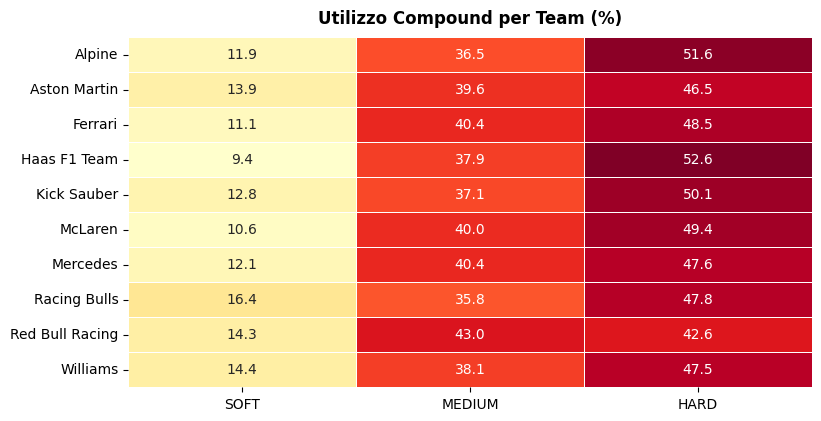

Grafico salvato in: Analysis/CompoundAnalysis/compound_usage_team


In [27]:
# Gomma Usata per Team

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 5)

top_teams = df_f1['Team'].value_counts().index
compound_usage = df_f1[df_f1['Team'].isin(top_teams)].pivot_table(
    values='LapNumber', index='Team', columns='Compound', aggfunc='count', fill_value=0
)
for col in ['SOFT','MEDIUM','HARD']:
    if col not in compound_usage.columns:
        compound_usage[col] = 0
compound_usage = compound_usage[['SOFT','MEDIUM','HARD']]

compound_percentage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100
sns.heatmap(compound_percentage, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar=False)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title('Utilizzo Compound per Team (%)', fontsize=12, fontweight='bold', pad=10)
plt.show()

save_plot(fig, "CompoundAnalysis", "compound_usage_team")

### Analisi Meteo

Grafico salvato in: Analysis/WeatherAnalysis/weather_distribution


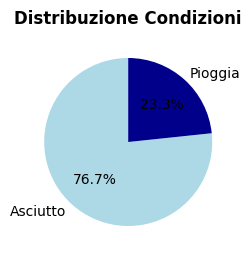

In [28]:
# Pioggia o Asciutto

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(2, 3, 6)
if 'Rainfall' in df_f1.columns:
    rainfall_counts = df_f1['Rainfall'].value_counts()
    colors_rain = ['lightblue', 'darkblue']
    ax.pie(rainfall_counts.values, labels=['Asciutto', 'Pioggia'],
           autopct='%1.1f%%', startangle=90, colors=colors_rain)
    ax.set_title('Distribuzione Condizioni', fontsize=12, fontweight='bold', pad=10)

    save_plot(fig, "WeatherAnalysis", "weather_distribution")

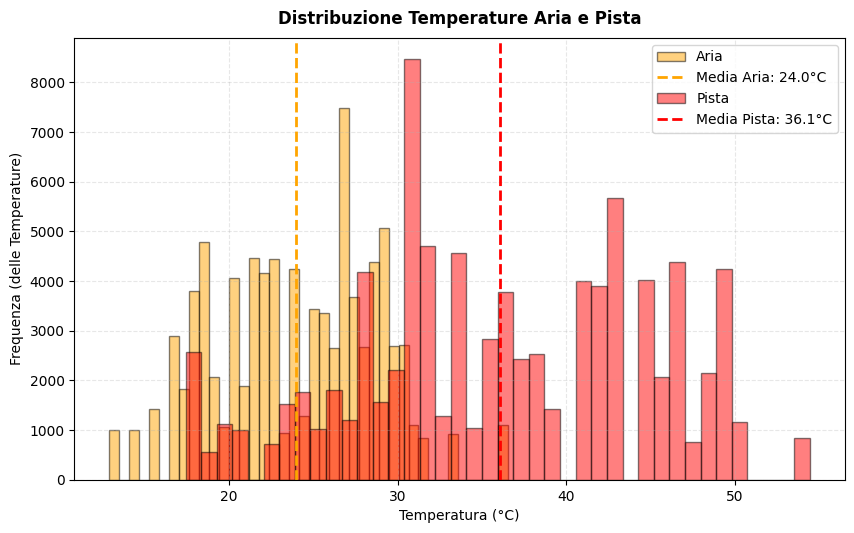

Grafico salvato in: Analysis/WeatherAnalysis/weather_temperature


In [29]:
# Temperatura Aria e Pista

fig = plt.figure(figsize=(25, 10))
ax = plt.subplot(2, 3, 3)

if 'AirTemp' in df_f1.columns:
    ax.hist(df_f1['AirTemp'], bins=40, edgecolor='black', alpha=0.5, color='orange', label='Aria')
    mean_temp = df_f1['AirTemp'].mean()
    ax.axvline(mean_temp, color='orange', linestyle='--', linewidth=2,
               label=f'Media Aria: {mean_temp:.1f}°C')

if 'TrackTemp' in df_f1.columns:
    ax.hist(df_f1['TrackTemp'], bins=40, edgecolor='black', alpha=0.5, color='red', label='Pista')
    mean_track = df_f1['TrackTemp'].mean()
    ax.axvline(mean_track, color='red', linestyle='--', linewidth=2,
               label=f'Media Pista: {mean_track:.1f}°C')

ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Frequenza (delle Temperature)')
ax.set_title('Distribuzione Temperature Aria e Pista', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

save_plot(fig, "WeatherAnalysis", "weather_temperature")

Grafico salvato in: Analysis/WeatherAnalysis/weather_windspeed


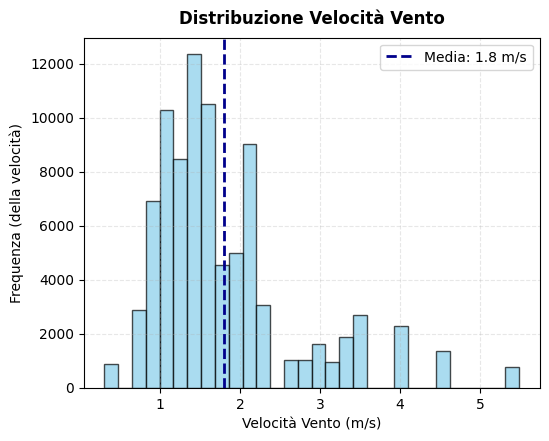

In [30]:
# Velocità del Vento

fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(2, 3, 5)
if 'WindSpeed' in df_f1.columns:
    ax.hist(df_f1['WindSpeed'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    mean_wind = df_f1['WindSpeed'].mean()
    ax.axvline(mean_wind, color='darkblue', linestyle='--', linewidth=2,
               label=f'Media: {mean_wind:.1f} m/s')
    ax.set_xlabel('Velocità Vento (m/s)')
    ax.set_ylabel('Frequenza (della velocità)')
    ax.set_title('Distribuzione Velocità Vento', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "WeatherAnalysis", "weather_windspeed")

Grafico salvato in: Analysis/WeatherAnalysis/weather_temp_vs_laptime


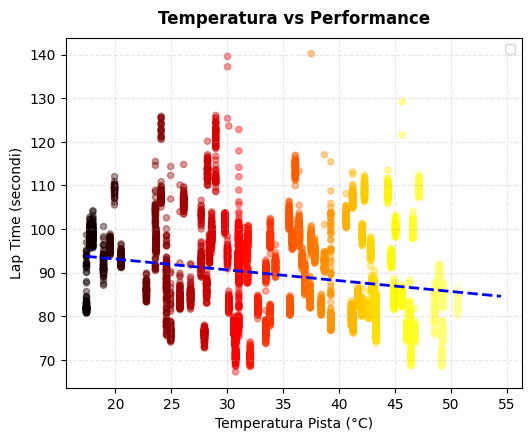

In [31]:
# Relazione Temperatura vs Lap Time

fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(2, 3, 3)
if 'TrackTemp' in df_f1.columns and 'LapTimeSec' in df_f1.columns:
    sample_data = df_f1.sample(min(9000, len(df_f1)))
    scatter = ax.scatter(sample_data['TrackTemp'], sample_data['LapTimeSec'],
                        c=sample_data['TrackTemp'], cmap='hot', alpha=0.4, s=20)
    z = np.polyfit(sample_data['TrackTemp'], sample_data['LapTimeSec'], 1)
    p = np.poly1d(z)
    ax.plot(sorted(sample_data['TrackTemp']), p(sorted(sample_data['TrackTemp'])),
            "b--", linewidth=2)
    ax.set_xlabel('Temperatura Pista (°C)')
    ax.set_ylabel('Lap Time (secondi)')
    ax.set_title('Temperatura vs Performance', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

save_plot(fig, "WeatherAnalysis", "weather_temp_vs_laptime")

### Analisi Circuiti

Grafico salvato in: Analysis/CircuitAnalysis/circuit_laptime


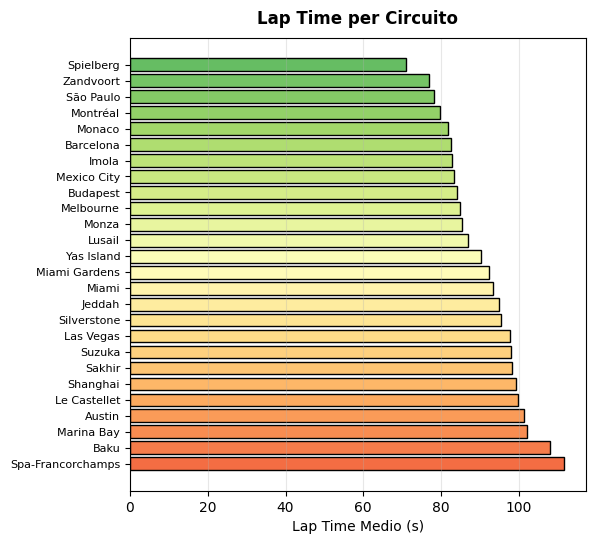

In [32]:
# Lap Time medio per Circuito

fig = plt.figure(figsize=(20, 20))
ax = plt.subplot(3, 3, 2)
top_circuits = df_f1['Circuit'].value_counts().index
circuit_laptimes = valid_laps[valid_laps['Circuit'].isin(top_circuits)].groupby('Circuit')['LapTimeSec'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(circuit_laptimes)))
ax.barh(range(len(circuit_laptimes)), circuit_laptimes.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(circuit_laptimes)))
ax.set_yticklabels(circuit_laptimes.index, fontsize=8)
ax.set_xlabel('Lap Time Medio (s)')
ax.set_title('Lap Time per Circuito', fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_laptime")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_count


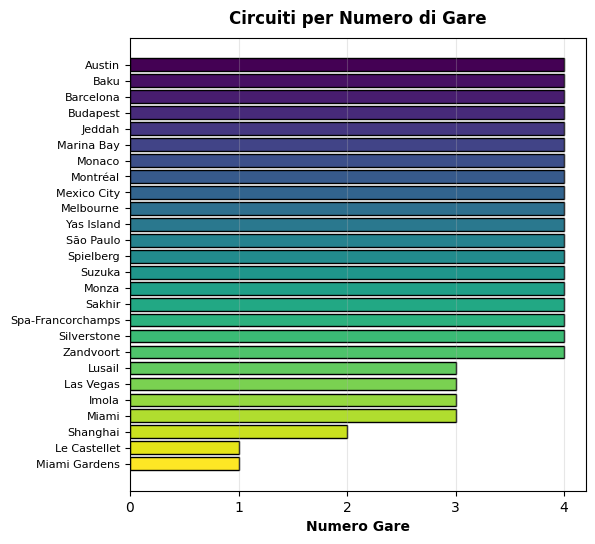

In [33]:
# Gare per Circuito nei 4 anni
fig = plt.figure(figsize=(20, 20))

ax = plt.subplot(3, 3, 1)
circuit_counts = df_f1.groupby('Circuit').apply(lambda x: x[['Year','Round']].drop_duplicates().shape[0]).sort_values(ascending=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(circuit_counts)))

ax.barh(range(len(circuit_counts)), circuit_counts.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(circuit_counts)))
ax.set_yticklabels(circuit_counts.index, fontsize=8)
ax.set_xlabel('Numero Gare', fontweight='bold')
ax.set_title('Circuiti per Numero di Gare', fontweight='bold', pad=10)
ax.set_xticks(range(0, circuit_counts.max() + 1))

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_count")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_temp


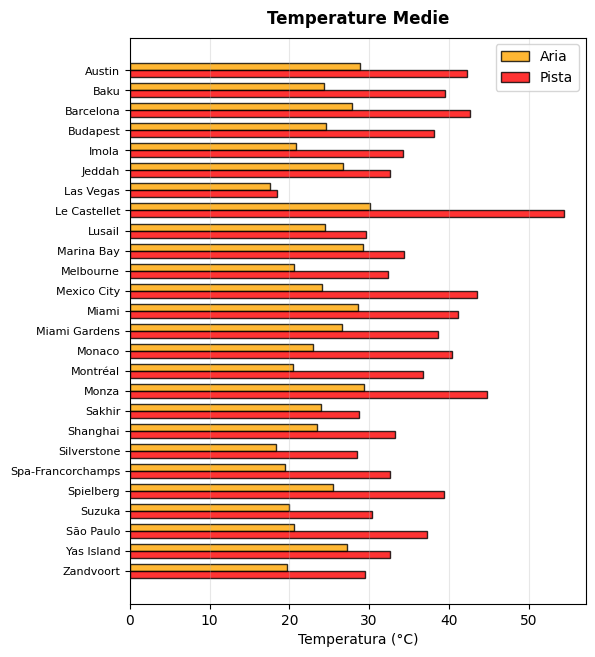

In [34]:
# Temperatura Media per Circuito
fig = plt.figure(figsize=(20, 25))

ax = plt.subplot(3, 3, 4)
circuit_temp = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')[['AirTemp', 'TrackTemp']].mean()
x = np.arange(len(circuit_temp))
width = 0.35
ax.barh(x - width/2, circuit_temp['AirTemp'], width, label='Aria', color='orange', alpha=0.8, edgecolor='black')
ax.barh(x + width/2, circuit_temp['TrackTemp'], width, label='Pista', color='red', alpha=0.8, edgecolor='black')
ax.set_yticks(x)
ax.set_yticklabels(circuit_temp.index, fontsize=8)
ax.set_xlabel('Temperatura (°C)')
ax.set_title('Temperature Medie', fontweight='bold', pad=10)
ax.legend()
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_temp")

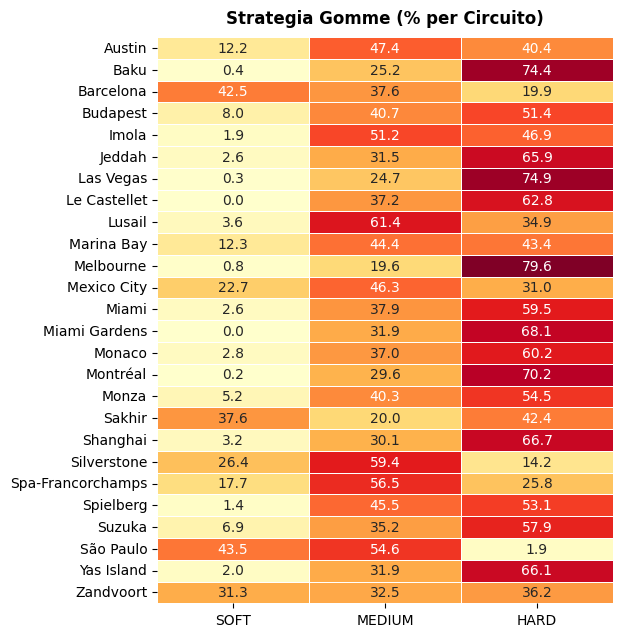

Grafico salvato in: Analysis/CircuitAnalysis/circuit_compound_usage


In [35]:
# Strategia Gomme per Circuito (in % per i vari anni)

fig = plt.figure(figsize=(20, 25))
ax = plt.subplot(3, 3, 6)

top_circuits = df_f1['Circuit'].value_counts().index
compound_usage = df_f1[df_f1['Circuit'].isin(top_circuits)].pivot_table(
    values='LapNumber', index='Circuit', columns='Compound', aggfunc='count', fill_value=0
)

for col in ['SOFT','MEDIUM','HARD']:
    if col not in compound_usage.columns:
        compound_usage[col] = 0
compound_usage = compound_usage[['SOFT','MEDIUM','HARD']]
compound_percentage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100
sns.heatmap(compound_percentage, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar=False)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title('Strategia Gomme (% per Circuito)', fontweight='bold', pad=10)
plt.show()

save_plot(fig, "CircuitAnalysis", "circuit_compound_usage")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_stint_length


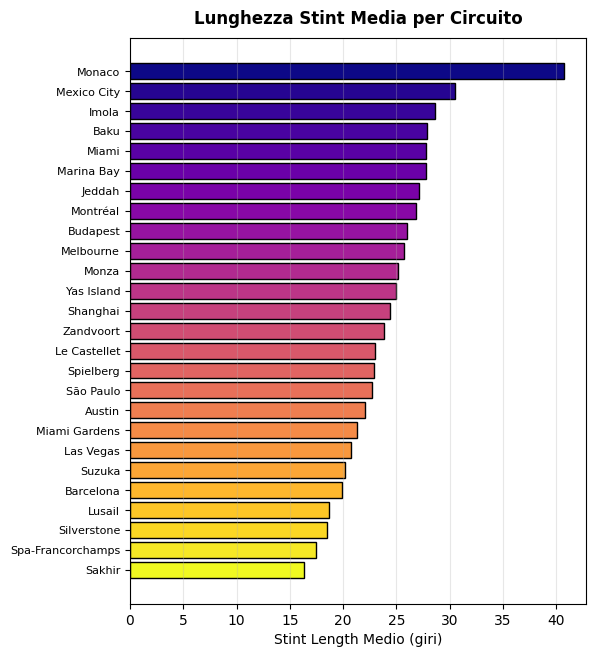

In [36]:
# Stint Length Medio per Circuito
fig = plt.figure(figsize=(20, 25))

ax = plt.subplot(3, 3, 7)
if 'StintLength' in df_f1.columns:
    stint_by_circuit = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')['StintLength'].mean().sort_values(ascending=False)
    colors = plt.cm.plasma(np.linspace(0, 1, len(stint_by_circuit)))
    ax.barh(range(len(stint_by_circuit)), stint_by_circuit.values, color=colors, edgecolor='black')
    ax.set_yticks(range(len(stint_by_circuit)))
    ax.set_yticklabels(stint_by_circuit.index, fontsize=8)
    ax.set_xlabel('Stint Length Medio (giri)')
    ax.set_title('Lunghezza Stint Media per Circuito', fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_stint_length")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_weather


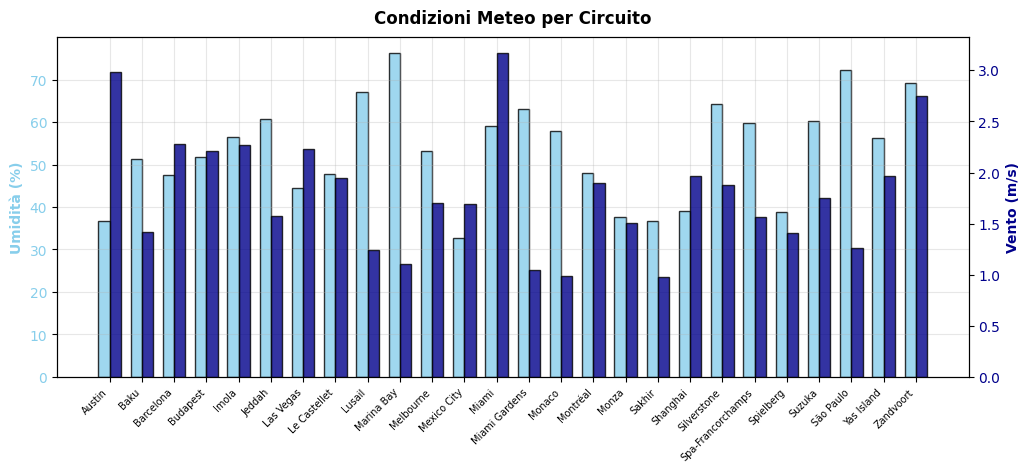

In [37]:
# Umidità e Vento per Circuito
fig = plt.figure(figsize=(40, 15))

ax = plt.subplot(3, 3, 8)
circuit_weather = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')[['Humidity', 'WindSpeed']].mean()
x = np.arange(len(circuit_weather))
ax_twin = ax.twinx()
ax.bar(x - width/2, circuit_weather['Humidity'], width, label='Umidità', color='skyblue', alpha=0.8, edgecolor='black')
ax_twin.bar(x + width/2, circuit_weather['WindSpeed'], width, label='Vento', color='darkblue', alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(circuit_weather.index, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Umidità (%)', fontweight='bold', color='skyblue')
ax_twin.set_ylabel('Vento (m/s)', fontweight='bold', color='darkblue')
ax.set_title('Condizioni Meteo per Circuito', fontweight='bold', pad=10)
ax.tick_params(axis='y', labelcolor='skyblue')
ax_twin.tick_params(axis='y', labelcolor='darkblue')
ax.grid(alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_weather")